In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
base_dir = "C:/Users/OWNER/Downloads/SDS-CP028-smart-leaf/submissions/team-members/Samsudeen/TrainValTestDir"
#"C:/Users/OWNER/Downloads/TrainValTestDir"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [3]:
img_size = (224, 224)
Batch_size = 64
# Data Generators with Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # Normalize pixels
    #rotation_range=20,              # Random rotation
    #width_shift_range=0.1,          # Horizontal shift
    #height_shift_range=0.1,         # Vertical shift
    #shear_range=0.1,                # Shearing
    #zoom_range=0.1,                 # Random zoom
    horizontal_flip=True,           # Random horizontal flip
    vertical_flip = True,            # Random Vertical flip
    #brightness_range =[0.5, 1.5],  # Random Brightness
    fill_mode='nearest'             # Filling strategy
)
# Validation/Test: Only Rescaling (NO Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
# Load datasets
train_generator = train_datagen.flow_from_directory(train_dir,
    target_size=img_size,
    batch_size=Batch_size ,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(val_dir,
    target_size=img_size,
    batch_size=Batch_size ,
    class_mode='categorical',
    shuffle=False
)

Found 12419 images belonging to 14 classes.
Found 1298 images belonging to 14 classes.


In [5]:
# 🔍 Compute class weights
labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(zip(np.unique(labels), class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: 0.9308199670214361, 1: 1.0572961008002724, 2: 0.9548669844687068, 3: 1.0436134453781511, 4: 1.0436134453781511, 5: 1.0713423050379571, 6: 1.0436134453781511, 7: 1.0497886728655959, 8: 0.745438175270108, 9: 1.0436134453781511, 10: 1.0460747978436657, 11: 1.0473098330241188, 12: 0.9944746957078796, 13: 1.0460747978436657}


In [6]:
# Load base ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*img_size, 3))
base_model.trainable = False  # Freeze convolutional base

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)


In [7]:
# Define full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_resnet_model.h5', save_best_only=True)
]

# Train the model with class weights
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights  #  Apply class weight here
)

C:\Users\OWNER\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1064 - loss: 2.8229

195/195 ━━━━━━━━━━━━━━━━━━━━ 574s 3s/step - accuracy: 0.1066 - loss: 2.8219 - val_accuracy: 0.3220 - val_loss: 2.2957
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2692 - loss: 2.2930

195/195 ━━━━━━━━━━━━━━━━━━━━ 1234s 6s/step - accuracy: 0.2693 - loss: 2.2927 - val_accuracy: 0.3567 - val_loss: 2.1506
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3511 - loss: 2.1207

195/195 ━━━━━━━━━━━━━━━━━━━━ 843s 4s/step - accuracy: 0.3512 - loss: 2.1205 - val_accuracy: 0.3898 - val_loss: 2.0203
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3967 - loss: 1.9821

...

195/195 ━━━━━━━━━━━━━━━━━━━━ 1001s 5s/step - accuracy: 0.5857 - loss: 1.2411 - val_accuracy: 0.6163 - val_loss: 1.2242
Epoch 17/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6090 - loss: 1.2028

195/195 ━━━━━━━━━━━━━━━━━━━━ 1024s 5s/step - accuracy: 0.6089 - loss: 1.2027 - val_accuracy: 0.6256 - val_loss: 1.1975
Epoch 18/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6123 - loss: 1.1747

195/195 ━━━━━━━━━━━━━━━━━━━━ 1025s 5s/step - accuracy: 0.6123 - loss: 1.1746 - val_accuracy: 0.6364 - val_loss: 1.1679
Epoch 19/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6058 - loss: 1.1591

195/195 ━━━━━━━━━━━━━━━━━━━━ 1017s 5s/step - accuracy: 0.6058 - loss: 1.1590 - val_accuracy: 0.6341 - val_loss: 1.1447
Epoch 20/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6155 - loss: 1.1384

195/195 ━━━━━━━━━━━━━━━━━━━━ 1007s 5s/step - accuracy: 0.6155 - loss: 1.1383 - val_accuracy: 0.6502 - val_loss: 1.1218


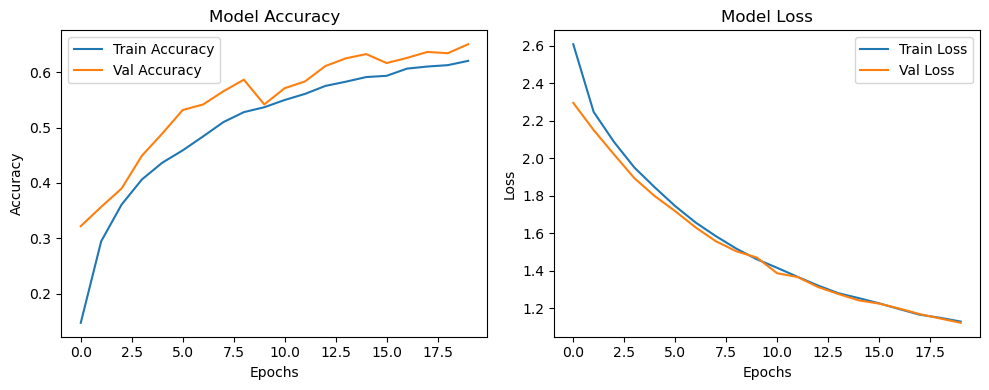

In [8]:
# Plot accuracy and loss
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Phase 2: Fine-tuning the Entire Model (Unfrozen Base)

In [9]:
from tensorflow.keras.models import Sequential
from kerastuner.tuners import RandomSearch

C:\Users\OWNER\AppData\Local\Temp\ipykernel_8388\3612844797.py:2: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [10]:
# Define search space
from kerastuner.engine.hyperparameters import HyperParameters
hp = HyperParameters()

In [11]:
hp_units = hp.Int('units', min_value=64, max_value=512, step=64)
hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
hp_lr = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])
hp_activation = hp.Choice('activation', values=['relu', 'tanh'])

In [12]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*img_size, 3))
base_model.trainable = True  # Freeze convolutional base

In [13]:
num_classes = 14

In [14]:
# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(hp_units, activation=hp_activation),
    Dropout(hp_dropout),
    Dense(num_classes, activation='softmax')  # Set num_classes accordingly
])

In [15]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=hp_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# Tuner setup
tuner = RandomSearch(
    hypermodel=lambda hp: model,  # Not using function form, just the built model
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='resnet_tune',
    project_name='resnet_hyperparam'
)

Reloading Tuner from resnet_tune\resnet_hyperparam\tuner0.json


In [18]:
# Perform search
tuner.search(train_generator, epochs=20, validation_data=val_generator)

In [19]:
# Get best model
best_model = tuner.get_best_models(num_models=1)[0]



C:\Users\OWNER\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 434 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
# Evaluate
loss, acc = best_model.evaluate(val_generator)
print(f"Best accuracy: {acc:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.8561 - loss: 0.3962
Best accuracy: 0.8459


# Evaluate the Model on the Test Set

In [21]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,  # path to test folder
    target_size=img_size,
    batch_size=Batch_size,
    class_mode='categorical',
    shuffle=False
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}")


Found 1312 images belonging to 14 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.8742 - loss: 0.3582
Test Accuracy: 0.86


# Classification Report and confusion matrix

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Labels
class_labels = list(test_generator.class_indices.keys())


21/21 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step


In [23]:
# Classification Report
print(classification_report(y_true, y_pred, target_names=class_labels))

                             precision    recall  f1-score   support

         Corn___Common_Rust       1.00      1.00      1.00       120
      Corn___Gray_Leaf_Spot       0.54      0.98      0.69        52
             Corn___Healthy       0.97      1.00      0.99       117
Corn___Northern_Leaf_Blight       1.00      0.68      0.81        99
      Potato___Early_Blight       1.00      0.51      0.68       100
           Potato___Healthy       0.83      0.94      0.88        16
       Potato___Late_Blight       0.78      0.85      0.81       100
          Rice___Brown_Spot       0.55      0.35      0.43        62
             Rice___Healthy       0.79      0.92      0.85       150
          Rice___Leaf_Blast       0.62      0.78      0.69        99
          Rice___Neck_Blast       0.99      0.98      0.98       100
         Wheat___Brown_Rust       0.99      0.98      0.98        91
            Wheat___Healthy       1.00      0.97      0.99       113
        Wheat___Yellow_Rust      

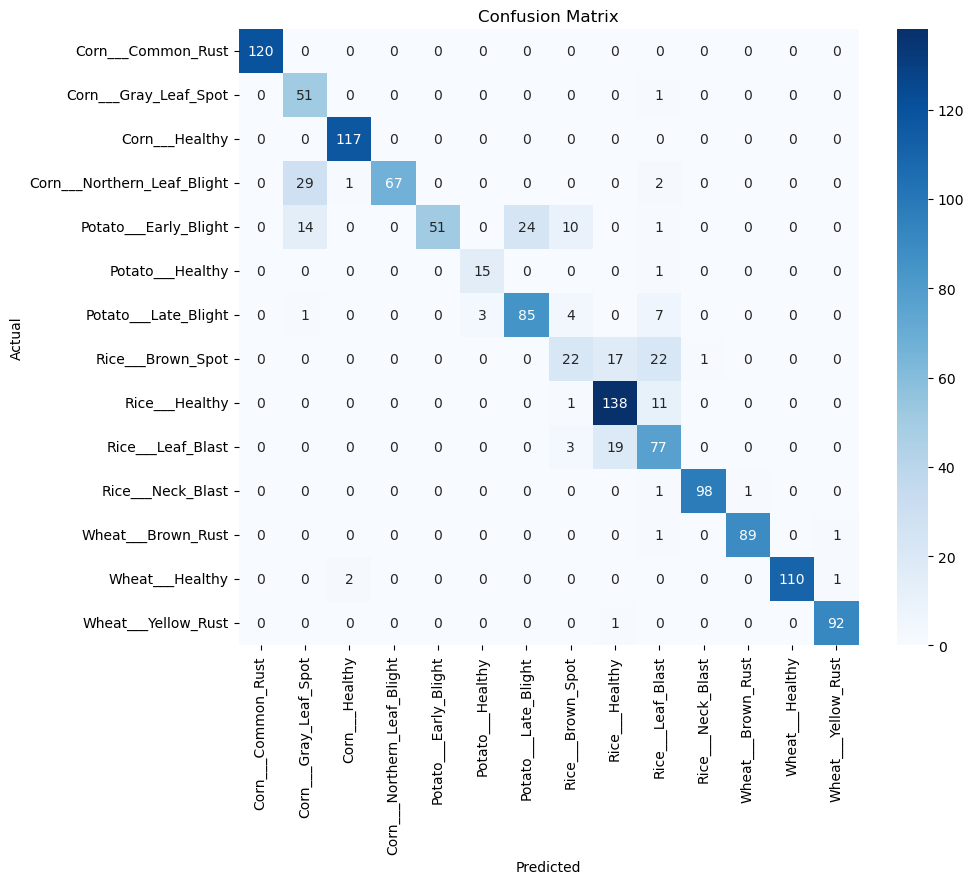

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the Model and Class Indices

In [25]:
# Save model
model.save("Smart_Leaf_resnet_model.h5")

# Save class labels
import pickle
with open("class_indices.pkl", "wb") as f:
    pickle.dump(train_generator.class_indices, f)
